In [1]:
library("devtools")
# check if patchwork is installed, if not install it
if (!requireNamespace("patchwork", quietly = TRUE)) {
    devtools::install_github("thomasp85/patchwork")
}
for (pkg in c(
    "ggplot2", "dplyr", "patchwork", "ggplotify"
    )) {
    # load the package quietly
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                pkg,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}
# load custom themes
source("../../utils/r_themes.r")

Loading required package: usethis



## load data

In [2]:
actual_results_file_path <- file.path("../../data/CP_aggregated/endpoints/aggregated_profile.parquet")
actual_results <- arrow::read_parquet(actual_results_file_path)
actual_results$Metadata_Time <- 13
actual_results$shuffled <- "not_shuffled"
train_test_splits_file_path <- file.path("../data_splits/train_test_wells.parquet")
# prepend Terminal to each non metadata column name
actual_results <- actual_results %>%
  rename_with(~ paste0("Terminal_", .), -c(Metadata_Time, Metadata_dose, Metadata_Well, shuffled))
actual_results$Metadata_shuffled <- "not_shuffled"
train_test_splits <- arrow::read_parquet(train_test_splits_file_path)
columns_to_keep <- colnames(actual_results)



results_file_path <- file.path("../results/all_terminal_features.parquet")
results <- arrow::read_parquet(results_file_path)

subset_results <- results[, colnames(results) %in% columns_to_keep]
# make dose a double
subset_results$Metadata_dose <- as.double(subset_results$Metadata_dose)

In [3]:
# drop the singlecells, compound, and control columns
actual_results <- actual_results %>%
  select(-c(
    'Terminal_Metadata_number_of_singlecells',
  'Terminal_Metadata_plate','Terminal_Metadata_compound','Terminal_Metadata_control'))
metadata_columns <- colnames(actual_results)[
  grepl("Metadata", colnames(actual_results)) &  # Contains "Metadata"
  !grepl("Terminal", colnames(actual_results)) 
]

actual_results_single_annexinV <- actual_results %>%
  select(c("Terminal_Cytoplasm_Intensity_UpperQuartileIntensity_AnnexinV", "Metadata_shuffled", "Metadata_Well", "Metadata_dose"))

single_feature <- "Terminal_Cytoplasm_Intensity_UpperQuartileIntensity_AnnexinV"


In [4]:

# rename metadata_shuffled to shuffled
actual_results$shuffled <- actual_results$Metadata_shuffled
actual_results_single_annexinV$shuffled <- actual_results$Metadata_shuffled
# drop the Metadata_shuffled column
actual_results <- actual_results %>%
  select(-Metadata_shuffled)
actual_results_single_annexinV <- actual_results_single_annexinV %>%
  select(-Metadata_shuffled)
# duplicate the actual results so that there are copies for the
# train model, test model, shuffled train model, and shuffled test model
actual_results <- rbind(actual_results, actual_results)
actual_results_single_annexinV <- rbind(actual_results_single_annexinV, actual_results_single_annexinV)
# add a column to indicate which model the row is for
actual_results$shuffled <- rep(c("shuffled", "not_shuffled"), each = nrow(actual_results) / 2)
actual_results_single_annexinV$shuffled <- rep(c("shuffled", "not_shuffled"), each = nrow(actual_results_single_annexinV) / 2)
# # rename the single feature column to have a suffix of "actual"
actual_results_single_annexinV <- actual_results_single_annexinV %>% rename(!!paste0(single_feature, "_actual") := single_feature)

# get only the last timepoints
subset_results <- subset_results %>% slice_max(order_by = Metadata_Time, n = 1)
# get only the single feature and the metadata columns
subset_results_single_feature <- subset_results %>% select(c(Metadata_Well, Metadata_dose, shuffled, single_feature))
# rename the single feature column to have a suffix of "predicted"
subset_results_single_feature <- subset_results_single_feature %>% rename(!!paste0(single_feature, "_predicted") := single_feature)
# merge the subset results and actual results
merged_results <- merge(subset_results_single_feature, actual_results_single_annexinV, by = c("Metadata_Well", "Metadata_dose", "shuffled"))


Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(single_feature)

  # Now:
  data %>% select(all_of(single_feature))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


In [5]:

# merge the two dataframes on the columns "Metadata_Time" and "Metadata_dose" Metadata_Well

merged_results$Metadata_dose <- as.numeric(merged_results$Metadata_dose)
merged_results$Metadata_dose <- factor(
    merged_results$Metadata_dose, 
    levels = c(
        '0',
        '0.61',
        '1.22',
        '2.44',
        '4.88',
        '9.77',
        '19.53',
        '39.06',
        '78.13',
        '156.25'
    )
)
merged_results$shuffled <- gsub("shuffled", "Shuffled", merged_results$shuffled)
merged_results$shuffled <- gsub("not_Shuffled", "Not shuffled", merged_results$shuffled)

merged_results <- merge(
    merged_results,
    train_test_splits,
    by = c("Metadata_Well")
)
merged_results$data_split <- gsub("train", "Train", merged_results$data_split)
merged_results$data_split <- gsub("test", "Test", merged_results$data_split)
merged_results$data_split <- factor(merged_results$data_split, levels = c("Train", "Test"))


In [6]:
# get the non shuffled min and max
non_shuffled_x_min <- merged_results %>% 
    filter(shuffled == "Not shuffled") %>% 
    pull(Terminal_Cytoplasm_Intensity_UpperQuartileIntensity_AnnexinV_actual) %>% 
    min() %>% round(2)

non_shuffled_x_max <- merged_results %>% 
    filter(shuffled == "Not shuffled") %>% 
    pull(Terminal_Cytoplasm_Intensity_UpperQuartileIntensity_AnnexinV_actual) %>% 
    max() %>% round(2)

non_shuffled_y_min <- merged_results %>% 
    filter(shuffled == "Not shuffled") %>% 
    pull(Terminal_Cytoplasm_Intensity_UpperQuartileIntensity_AnnexinV_predicted) %>% 
    min() %>% round(2)

non_shuffled_y_max <- merged_results %>% 
    filter(shuffled == "Not shuffled") %>% 
    pull(Terminal_Cytoplasm_Intensity_UpperQuartileIntensity_AnnexinV_predicted) %>% 
    max() %>% round(2)

# get the min and max for the shuffled data
global_square_min <- if (non_shuffled_x_min < non_shuffled_y_min) {
    non_shuffled_x_min
} else {
    non_shuffled_y_min
}

global_square_max <- if (non_shuffled_x_max > non_shuffled_y_max) {
    non_shuffled_x_max
} else {
    non_shuffled_y_max
}


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


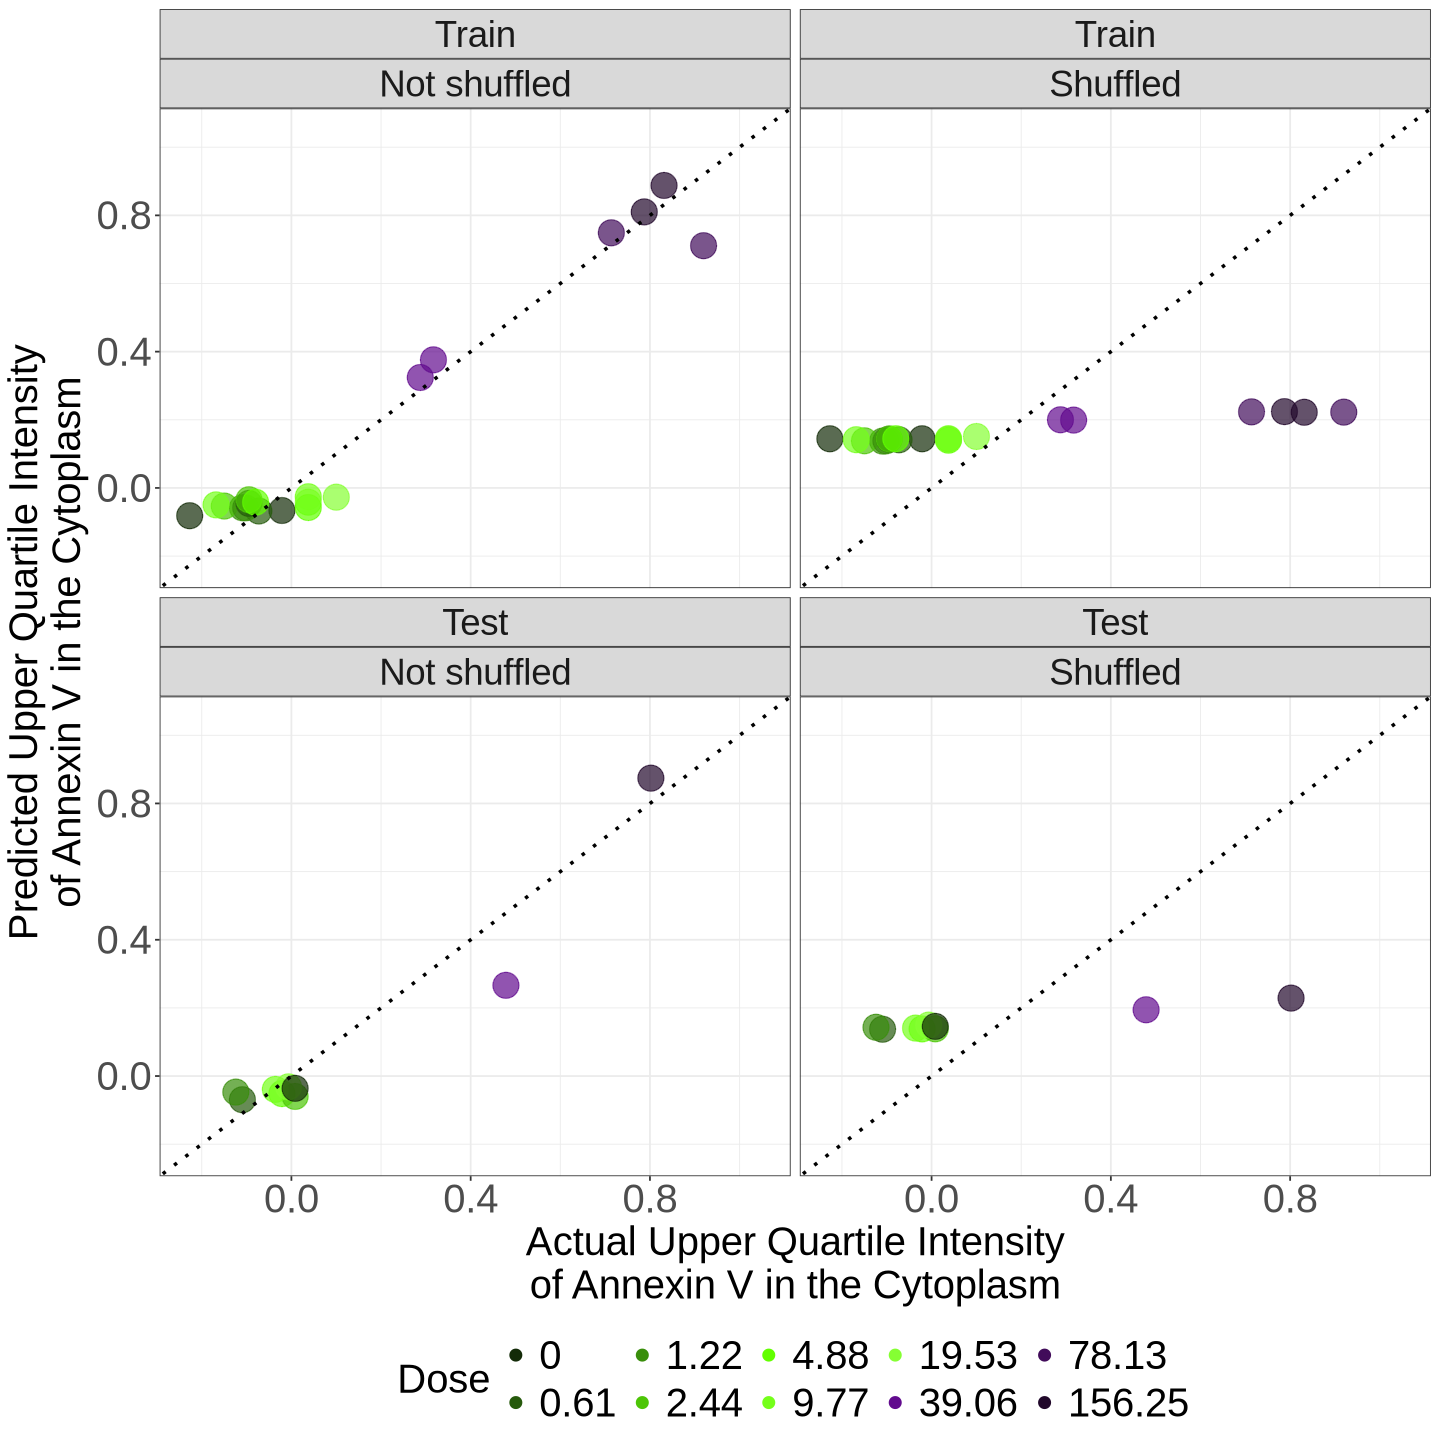

In [7]:
width <- 12
height <- 12
options(repr.plot.width = width, repr.plot.height = height)
# plot the actual vs the predicted values
actual_vs_predicted_plot <- (
    ggplot(merged_results, aes(
        x = Terminal_Cytoplasm_Intensity_UpperQuartileIntensity_AnnexinV_actual, 
        y = Terminal_Cytoplasm_Intensity_UpperQuartileIntensity_AnnexinV_predicted,
        color = Metadata_dose
        )
    )
    + geom_point(size = 7, alpha = 0.7)
    + labs(x = "Actual Upper Quartile Intensity\nof Annexin V in the Cytoplasm", y = "Predicted Upper Quartile Intensity\nof Annexin V in the Cytoplasm")
    + scale_color_manual(values = color_palette_dose)
    # + dose_guides_color
    + theme(
        # axis tick labels
        axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    )
    + guides(color = guide_legend(title = "Dose", override.aes = list(size = 3, alpha = 1)))
       + facet_wrap(data_split~shuffled)
    + xlim(
        global_square_min,
        global_square_max
    )
    + ylim(
        global_square_min,
        global_square_max
    )
    # make the plot square
    + theme(
        aspect.ratio = 1
    )
    #  plot the y=x line as a dotted line
    + geom_abline(slope = 1, intercept = 0, color = "black", size = 1, linetype = "dotted")
    + theme_bw()
    + plot_themes

 
)
ggsave("../figures/actual_vs_predicted.png", actual_vs_predicted_plot, width = width, height = height, dpi = 600)
actual_vs_predicted_plot
